<h4><b>IMPORTING LIBRARIES</b></h4>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("Telco-Customer-Churn.csv")

<h4><b>STRUCTURE OF DATA</b></h4>


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<h4><b>INFORMATION OF DATA (USING df.info())</b></h4>

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


<h4><b>CLEANING THE COLUMNS</b></h4>

In [7]:
df['TotalCharges'] = df['TotalCharges'].replace(" ",np.nan)

In [8]:
df['TotalCharges'] = df['TotalCharges'].astype("float")
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())


In [9]:
df['Churn'] = df['Churn'].replace(('No','Yes'),(0,1))

C:\Users\Admin\AppData\Local\Temp\ipykernel_21648\3242825739.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace(('No','Yes'),(0,1))


<h4><b>FILTERING REQUIRE COLUMNS AND STORING THE DATA</b></h4>


In [10]:
data  = df.iloc[:,[1,3,5,6,8,15,16,17,18,19,20]]

In [11]:
#data.to_csv("cleaned_telco_churn.csv",index=False)

<h4><b>EXPLORATORY DATA ANALYSIS</b></h4>


In [12]:
data.head()

,gender,Partner,tenure,PhoneService,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,Yes,1,No,DSL,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,No,34,Yes,DSL,One year,No,Mailed check,56.95,1889.50,0
2,Male,No,2,Yes,DSL,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,No,45,No,DSL,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,No,2,Yes,Fiber optic,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [13]:
total_churned = data['Churn'].value_counts()[1]


<h4><b>Churn Distribution</b><h4>

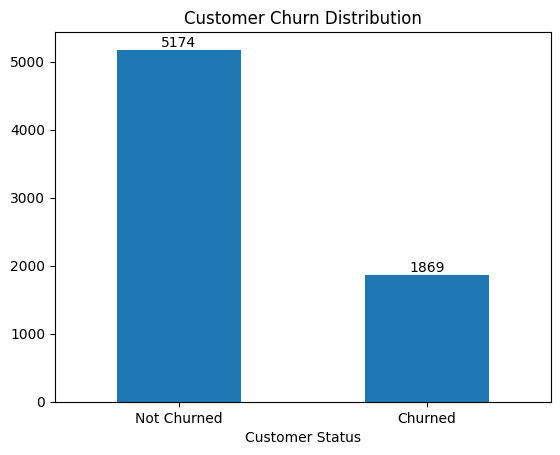

In [25]:
#overall churn vs retention

res = data['Churn'].value_counts().plot(kind='bar')
plt.xticks([0,1],['Not Churned','Churned'],rotation=0)
plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")

for container in res.containers:
    res.bar_label(container)
plt.show()


<h4><b>Gender-wise Customer Churn Analysis</b></h4>

Female not churned: 2549
Female chrned: 939

Male not churned: 2625
Male churned: 930

Female churned percentage in total churn:,50.24%
Male chrned percentage in total churn:,49.76%

Female churn rate:,26.92%
Male churn rate:,26.16%


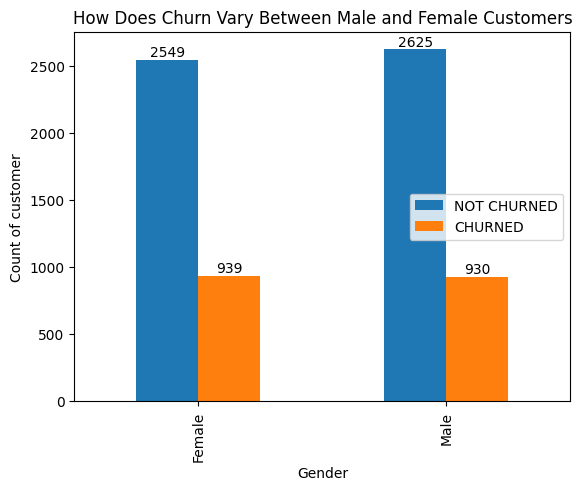

In [26]:
#gender effect on churn
gender_based = pd.crosstab(data['gender'],data['Churn'])
print("Female not churned:",gender_based.iloc[0,0])
print("Female chrned:",gender_based.iloc[0,1])
print("\nMale not churned:",gender_based.iloc[1,0])
print("Male churned:",gender_based.iloc[1,1])

print(f"\nFemale churned percentage in total churn:,{gender_based.iloc[0,1]*100 / total_churned:.2f}%")
print(f"Male chrned percentage in total churn:,{gender_based.iloc[1,1]*100/total_churned:.2f}%")

total_female = gender_based.loc['Female',0] + gender_based.loc['Female',1]
total_male = gender_based.loc['Male',0] + gender_based.loc['Male',1]

print(f"\nFemale churn rate:,{gender_based.loc['Female',1] *100/ total_female:.2f}%")
print(f"Male churn rate:,{gender_based.loc['Male',1] *100/ total_male:.2f}%")

x = gender_based.plot(kind='bar')
x.legend(['NOT CHURNED','CHURNED'])
plt.title("How Does Churn Vary Between Male and Female Customers")
plt.xlabel("Gender")
plt.ylabel("Count of customer")
for info in x.containers:
    x.bar_label(info)
plt.show()

<h4><b>INSIGHT:Gender Has Minimal Impact on Customer Churn</b></h4>

Female customers contributed approximately <b>50.24%</b> of the total churned customers, while male customers contributed around <b>49.76%</b>. The churn distribution between genders is almost equal, indicating that gender does not significantly influence customer churn behavior.

<h4><b>Partner Status and Customer Churn Analysis</b></h4>


Customers without partners in total churn:,64.21%
Customers with partners in total churn:,35.79%


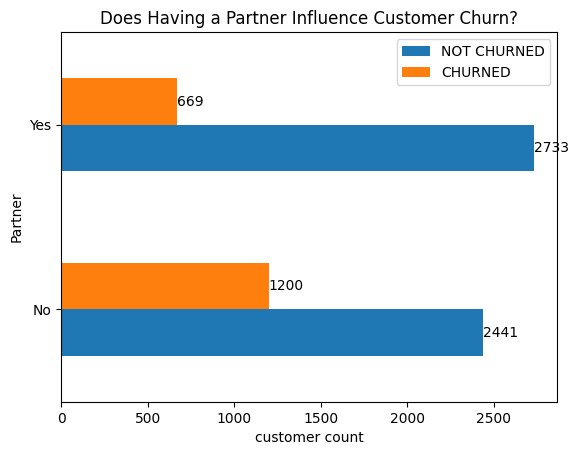

In [27]:
partner_churn = pd.crosstab(data['Partner'],data['Churn'])
partner_churn
no_partner = partner_churn.iloc[0,0] + partner_churn.iloc[0,1]
partner = partner_churn.iloc[1,0] + partner_churn.iloc[1,1]

#churn percent
print(f"Customers without partners in total churn:,{partner_churn.iloc[0,1]*100/ total_churned:.2f}%")
print(f"Customers with partners in total churn:,{partner_churn.iloc[1,1]*100/ total_churned:.2f}%")

x = partner_churn.plot(kind='barh')
x.legend(['NOT CHURNED','CHURNED'])
plt.title("Does Having a Partner Influence Customer Churn?")
plt.xlabel("customer count")

for info in x.containers:
    x.bar_label(info)
plt.show()

<h4><b>INSIGHT:Customers Without Partners Churn More</b></h4>

Customers without partners contributed the highest share of churn <b>64.21%</b>, while customers with partners contributed only <b>35.79%</b>. This indicates that customers without partners are more likely to leave the service.

<h4><b>Phone Service and Customer Churn Analysis</h4></b>

Churn rate among customers without phone service:,24.93%
Churn rate among customers with phone service:,26.71%


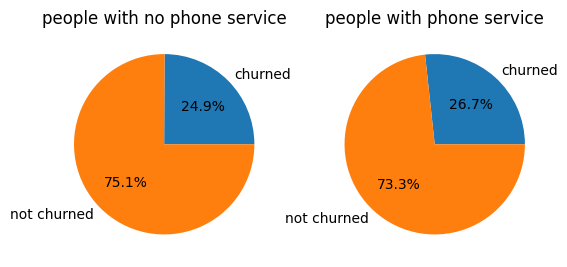

In [ ]:
phone_service = pd.crosstab(data['PhoneService'],data['Churn'])
total_no  = phone_service.iloc[0,0] + phone_service.iloc[0,1]
total_yes = phone_service.iloc[1,0] + phone_service.iloc[1,1]
no_phone_churn = phone_service.iloc[0,1] *100/ total_no
phone_churn = phone_service.iloc[1,1] *100/ total_yes
print(f"Churn rate among customers without phone service:,{no_phone_churn:.2f}%")
print(f"Churn rate among customers with phone service:,{phone_churn:.2f}%")

plt.subplot(121)
value = [no_phone_churn,(phone_service.iloc[0,0] *100/ total_no)]
labels = ["churned","not churned"]
plt.pie(value,labels=labels,autopct = '%1.1f%%')
plt.title("people with no phone service")


plt.subplot(122)
value = [phone_churn,(phone_service.iloc[1,0] *100/ total_yes)]
labels = ["churned","not churned"]
plt.pie(value,labels=labels,autopct = '%1.1f%%')
plt.title("people with phone service")
plt.show()


<h4><b>INSIGHT:Phone Service Has Minimal Impact on Churn</b></h4>
Customers with phone service showed a churn rate of <b>26.71%</b>, while customers without phone service had a churn rate of <b>24.93%</b>. The difference is very small, indicating that phone service does not significantly affect customer churn.

<h4><b>Internet Service and Customer Churn Analysis</b></h4>

Churn rate among DSL users:18.96%
Churn rate among Fiber Optic users:41.89%
Churn rate among customers without internet service:7.40%


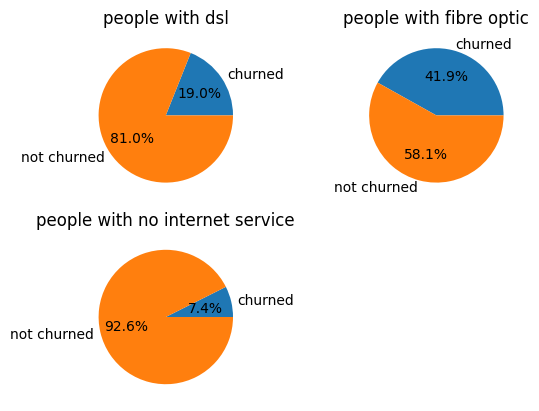

In [ ]:
internet_service = pd.crosstab(data['InternetService'],data['Churn'])
dsl = internet_service.iloc[0,0] + internet_service.iloc[0,1]
fibre_optic = internet_service.iloc[1,0] + internet_service.iloc[1,1]
no_service  = internet_service.iloc[2,0] + internet_service.iloc[2,1]

churn_in_dsl = internet_service.iloc[0,1] *100 / dsl
churn_in_fibre_optic =  internet_service.iloc[1,1] *100 / fibre_optic
churn_in_no_service = internet_service.iloc[2,1] *100 / no_service

print(f"Churn rate among DSL users:{churn_in_dsl:.2f}%")
print(f"Churn rate among Fiber Optic users:{churn_in_fibre_optic:.2f}%")
print(f"Churn rate among customers without internet service:{churn_in_no_service:.2f}%")

plt.subplot(221)
value = [churn_in_dsl,(internet_service.iloc[0,0] *100/ dsl)]
labels = ["churned","not churned"]
plt.pie(value,labels=labels,autopct = '%1.1f%%')
plt.title("people with dsl")

plt.subplot(222)
value = [churn_in_fibre_optic,(internet_service.iloc[1,0] *100/ fibre_optic)]
labels = ["churned","not churned"]
plt.pie(value,labels=labels,autopct = '%1.1f%%')
plt.title("people with fibre optic")

plt.subplot(223)
value = [churn_in_no_service,(internet_service.iloc[2,0] *100/ no_service)]
labels = ["churned","not churned"]
plt.pie(value,labels=labels,autopct = '%1.1f%%')
plt.title("people with no internet service")

plt.show()


<h4><b>INSIGHT:Fiber Optic Customers Show Highest Churn</b></h4>

Customers using Fiber Optic internet service had the highest churn rate at <b>41.89%</b>, compared to DSL users at <b>18.96%</b> and customers without internet service at only <b>7.40%</b>. This indicates that Fiber Optic customers are more likely to leave the service.

<h4><b>Contract Type and Customer Churn Analysis</b></h4>

Churn rate in month-to-month contracts:42.71%
Churn rate in one-year contracts:11.27%
Churn rate in two-year contracts:2.83%


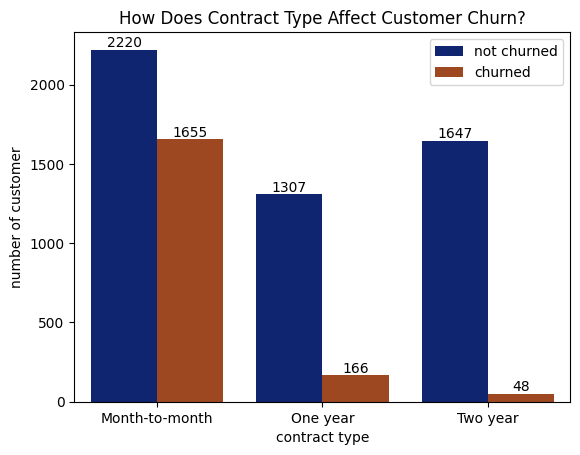

In [28]:
contract_type = pd.crosstab(df['Contract'],df['Churn'])
m_t_m = contract_type.iloc[0,0] + contract_type.iloc[0,1]
one = contract_type.iloc[1,0] + contract_type.iloc[1,1]
two = contract_type.iloc[2,0] + contract_type.iloc[2,1]

churn_month_to_month = contract_type.iloc[0,1] *100 / m_t_m
churn_one_year = contract_type.iloc[1,1]*100 / one
churn_two_year = contract_type.iloc[2,1]*100 / two

print(f"Churn rate in month-to-month contracts:{churn_month_to_month:.2f}%")
print(f"Churn rate in one-year contracts:{churn_one_year:.2f}%")
print(f"Churn rate in two-year contracts:{churn_two_year:.2f}%")

contract_visuals = sns.countplot(x='Contract',hue='Churn',palette='dark',data=data)
contract_visuals.legend(['not churned','churned'])
plt.title("How Does Contract Type Affect Customer Churn?")
plt.xlabel('contract type')
plt.ylabel("number of customer")
for info in contract_visuals.containers:
    contract_visuals.bar_label(info)
plt.show()

<h4><b>INSIGHT:Month-to-Month Customers Churn the Most</b></h4>

Customers with month-to-month contracts had the highest churn rate at <b>42.71%</b>, while one-year contract customers had a churn rate of <b>11.27%</b> and two-year contract customers had the lowest churn rate at <b>2.83%</b>. This shows that long-term contracts help improve customer retention and reduce churn.

<h4><b>Paperless Billing and Customer Churn Analysis</b></h4>

Paper billing contribution in total churn:25.09%
Paperless billing contribution in total churn:74.91%
Churn rate among paper billing customers:16.33%
Churn rate among paperless billing customers:33.57%


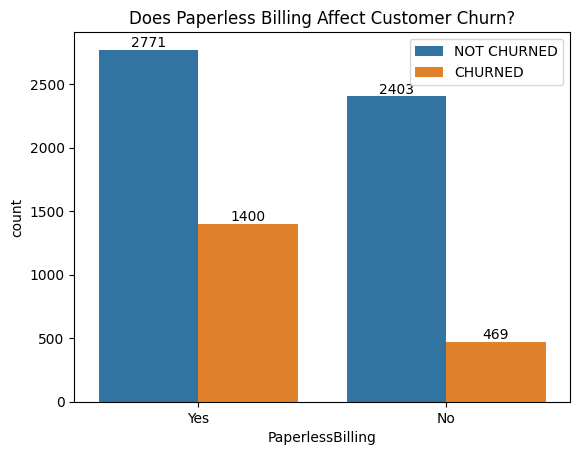

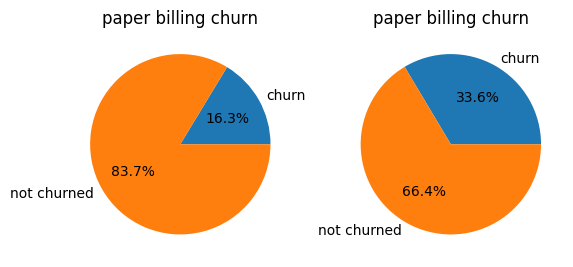

In [32]:
paperless_billing = pd.crosstab(data['PaperlessBilling'],data['Churn'])
print(f'Paper billing contribution in total churn:{paperless_billing.iloc[0,1]*100 / total_churned:.2f}%')
print(f'Paperless billing contribution in total churn:{paperless_billing.iloc[1,1]*100/total_churned:.2f}%')

paper = paperless_billing.iloc[0,0] + paperless_billing.iloc[0,1]
paperless = paperless_billing.iloc[1,0] + paperless_billing.iloc[1,1]

churn_in_paper = paperless_billing.iloc[0,1] *100 / paper
churn_in_paperless = paperless_billing.iloc[1,1]*100 / paperless
print(f"Churn rate among paper billing customers:{churn_in_paper:.2f}%")
print(f"Churn rate among paperless billing customers:{churn_in_paperless:.2f}%")

pl_plot = sns.countplot(x = data['PaperlessBilling'],hue='Churn',data=data)
pl_plot.legend(['NOT CHURNED','CHURNED'])
plt.title("Does Paperless Billing Affect Customer Churn?")
for info in pl_plot.containers:
    pl_plot.bar_label(info)
plt.show()

plt.subplot(121)
value = [churn_in_paper,paperless_billing.iloc[0,0] *100 / paper]
label = ['churn','not churned']
plt.pie(value,labels=label,autopct='%1.1f%%')
plt.title("paper billing churn")

plt.subplot(122)
value = [churn_in_paperless,paperless_billing.iloc[1,0] *100 / paperless]
label = ['churn','not churned']
plt.pie(value,labels=label,autopct='%1.1f%%')
plt.title("paper billing churn")
plt.show()

<h4><b>INSIGHT:Paperless Billing Customers Show Higher Churn</b></h4>

Customers using paperless billing contributed <b>74.91%</b> of the total churned customers and had a churn rate of <b>33.57%</b>, which is much higher than paper billing customers with a churn rate of <b>16.33%</b>. This indicates that customers using paperless billing are more likely to churn.

<h4><b>Payment Method and Customer Churn Analysis</b></h4>

ANALYZING OVERALL CHURN
Bank transfer contribution in total churn:,13.80%
Credit card contribution in total churn:,12.41%
Electronic check contribution in total churn:,57.30%
Mailed check contribution in total churn:,16.48%


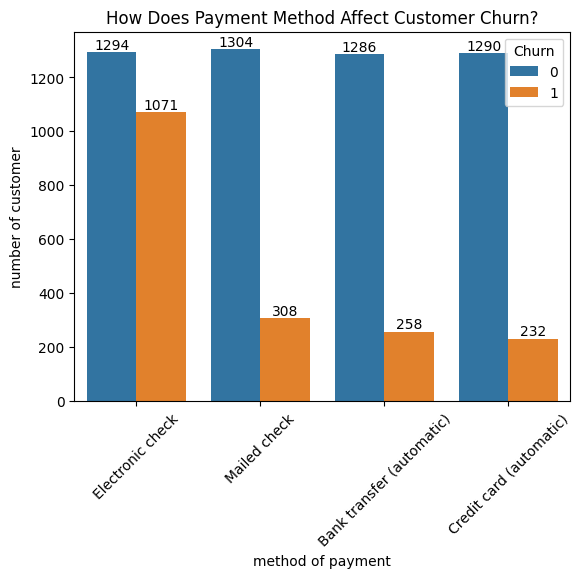

ANALYZING CHURN IN EACH CATEROGY
Churn rate among bank transfer customers:,16.71%
Churn rate among credit card customers:,15.24%
Churn rate among electronic check customers:,45.29%
Churn rate among mailed check customers:,19.11%


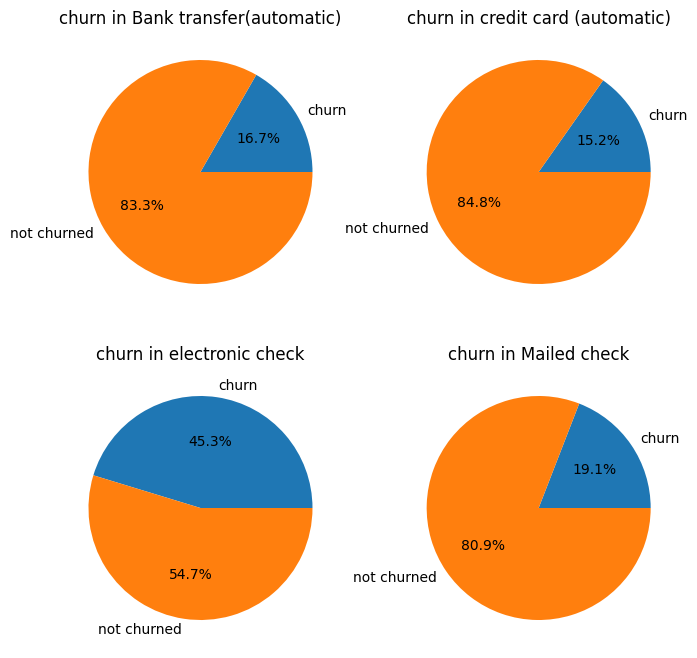

In [33]:
payment_method= pd.crosstab(data['PaymentMethod'],data['Churn'])

total_bank_transfer = payment_method.loc['Bank transfer (automatic)',0] + payment_method.loc['Bank transfer (automatic)',1]
total_credit_card = payment_method.loc['Credit card (automatic)',0] + payment_method.loc['Credit card (automatic)',1]
total_elec_check = payment_method.loc['Electronic check',0] + payment_method.loc['Electronic check',1]
total_mail_check = payment_method.loc['Mailed check',0] + payment_method.loc['Mailed check',1]

#overall
print("ANALYZING OVERALL CHURN")
overall_bank_in_churn =  payment_method.loc['Bank transfer (automatic)',1] *100 / total_churned
overall_creditcard_in_churn = payment_method.loc['Credit card (automatic)',1] *100 / total_churned
overall_elec_in_churn = payment_method.loc['Electronic check',1]*100 / total_churned
overall_mail_in_churn = payment_method.loc['Mailed check',1]*100 / total_churned

print("Bank transfer contribution in total churn:,{data:.2f}%".format(data = overall_bank_in_churn))
print("Credit card contribution in total churn:,{data:.2f}%".format(data = overall_creditcard_in_churn))
print("Electronic check contribution in total churn:,{data:.2f}%".format(data = overall_elec_in_churn))
print("Mailed check contribution in total churn:,{data:.2f}%".format(data = overall_mail_in_churn))
#overall visual
ax = sns.countplot(x = 'PaymentMethod' , hue = 'Churn' , data =data)
plt.title("How Does Payment Method Affect Customer Churn?")
plt.xlabel("method of payment")
plt.ylabel("number of customer")
plt.xticks(rotation = 45)
for info in ax.containers:
    ax.bar_label(info)
plt.show()

#for each category 
print("ANALYZING CHURN IN EACH CATEROGY")
print(f"Churn rate among bank transfer customers:,{payment_method.loc['Bank transfer (automatic)',1]*100 / total_bank_transfer:.2f}%")
print(f"Churn rate among credit card customers:,{payment_method.loc['Credit card (automatic)',1]*100 / total_credit_card:.2f}%")
print(f"Churn rate among electronic check customers:,{payment_method.loc['Electronic check',1]*100 / total_elec_check:.2f}%")
print(f"Churn rate among mailed check customers:,{payment_method.loc['Mailed check',1]*100 / total_mail_check:.2f}%")

#visulas on each category
plt.figure(figsize=(8,8))
plt.subplot(221)
value = [(payment_method.loc['Bank transfer (automatic)',1]*100 / total_bank_transfer),payment_method.loc['Bank transfer (automatic)',0]*100 / total_bank_transfer]
label = ['churn','not churned']
plt.pie(value,labels=label,autopct='%1.1f%%')
plt.title("churn in Bank transfer(automatic)")

plt.subplot(222)
value = [(payment_method.loc['Credit card (automatic)',1]*100 / total_credit_card),(payment_method.loc['Credit card (automatic)',0]*100 / total_credit_card)]
label = ['churn','not churned']
plt.pie(value,labels=label,autopct='%1.1f%%')
plt.title("churn in credit card (automatic)")


plt.subplot(223)
value = [(payment_method.loc['Electronic check',1]*100 / total_elec_check),(payment_method.loc['Electronic check',0]*100 / total_elec_check)]
label = ['churn','not churned']
plt.pie(value,labels=label,autopct='%1.1f%%')
plt.title("churn in electronic check")


plt.subplot(224)
value = [(payment_method.loc['Mailed check',1]*100 / total_mail_check),(payment_method.loc['Mailed check',0]*100 / total_mail_check)]
label = ['churn','not churned']
plt.pie(value,labels=label,autopct='%1.1f%%')
plt.title("churn in Mailed check")
plt.show()


<h4><b>INSIGHT:Electronic Check Customers Have the Highest Churn</b></h4>

Customers using electronic check had the highest churn rate at <b>45.29%</b> and contributed <b>57.30%</b> of the total churned customers. In comparison, customers using automatic payment methods such as bank transfer and credit card showed much lower churn rates. This indicates that payment method has a strong impact on customer churn.

<h4><b>Tenure and Customer Churn Analysis</b></h4>


Summary of Data
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

Average tenure of churned customers: 18 months
Average tenure of retained customers: 38 months


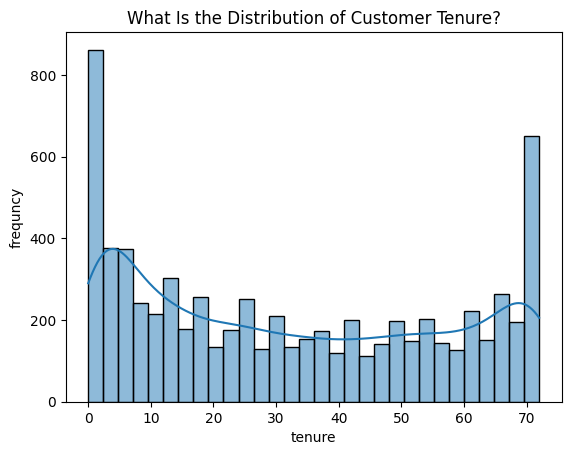

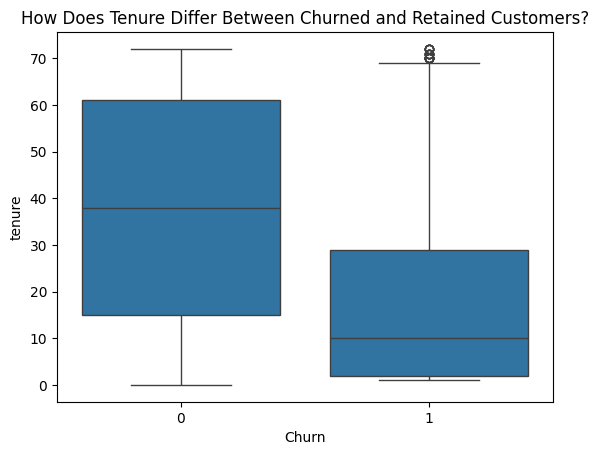

Churn percentage across different tenure groups
Churn                 0          1
tenure_group                      
0-1 Year      52.321839  47.678161
1-2 Years     71.289062  28.710938
2-4 Years     79.611041  20.388959
4-6 Years     90.486824   9.513176


C:\Users\Admin\AppData\Local\Temp\ipykernel_20196\1621756407.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'tenure_group'] = pd.cut(data['tenure'],


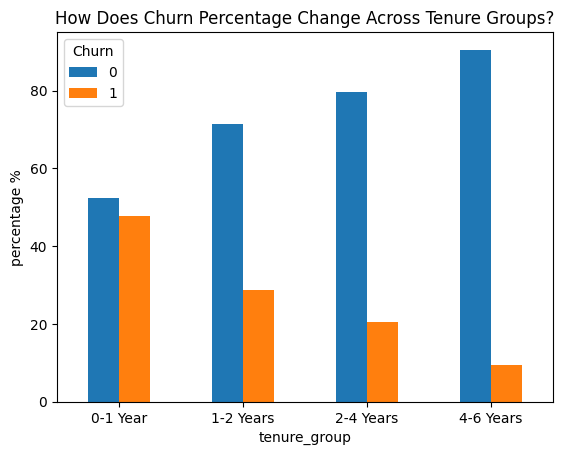

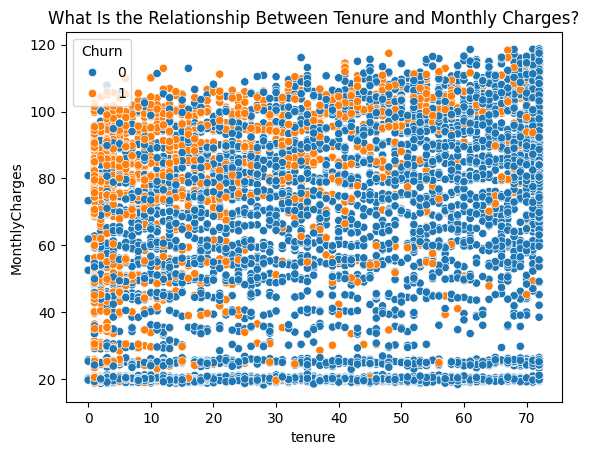

In [ ]:
print("Summary of Data")
print(data['tenure'].describe())

#average tenure based on churn
print("\nAverage tenure of churned customers:",round(data.groupby('Churn')['tenure'].mean()[1]),"months")
print("Average tenure of retained customers:",round(data.groupby('Churn')['tenure'].mean()[0]),'months')

#plot the distribution
sns.histplot(x='tenure',data=data,kde=True,bins=30)
plt.title("What Is the Distribution of Customer Tenure?")
plt.xlabel("tenure")
plt.ylabel("frequncy")
plt.show()

#box plot
sns.boxplot(x='Churn',y='tenure',data=data)
plt.title("How Does Tenure Differ Between Churned and Retained Customers?")
plt.show()

#grouping
bins = [0,12,24,48,72]
labels = ['0-1 Year','1-2 Years','2-4 Years','4-6 Years']

data.loc[:,'tenure_group'] = pd.cut(data['tenure'],
                            bins=bins,
                            labels=labels)

tenure_per = pd.crosstab(data['tenure_group'],data['Churn'],normalize='index')*100
print("Churn percentage across different tenure groups")
print(tenure_per)
tenure_per.plot(kind='bar')
plt.title("How Does Churn Percentage Change Across Tenure Groups?")
plt.xticks(rotation=0)
plt.ylabel("percentage %")
plt.show()

#relationship between tenure and monthly charges
sns.scatterplot(x='tenure',y='MonthlyCharges',hue='Churn',data=data)
plt.title("What Is the Relationship Between Tenure and Monthly Charges?")
plt.show()

<h4><b>INSIGHT:Customers With Lower Tenure Are More Likely to Churn</b></h4>

Customers with shorter tenure showed significantly higher churn rates compared to long-term customers. The average tenure of churned customers was only <b>18 months</b>, while retained customers stayed for around <b>38 months</b>. Churn percentage also decreased steadily as tenure increased, indicating that customer loyalty improves over time.

<h4><b>Monthly Charges and Customer Churn Analysis</b></h4>

Summary of Data
count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

Average monthly charges of churned customers:74.44%
Average monthly charges of retained customers:61.27%


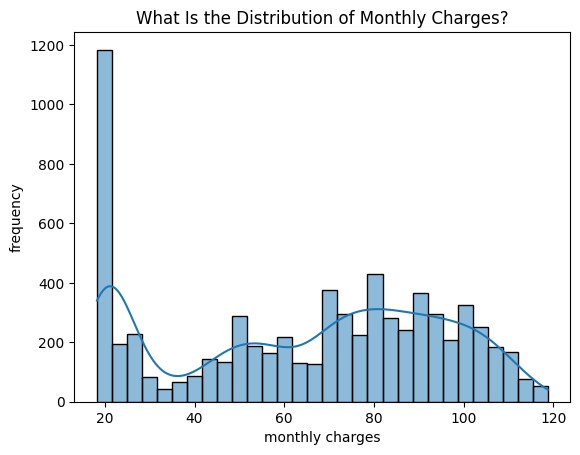

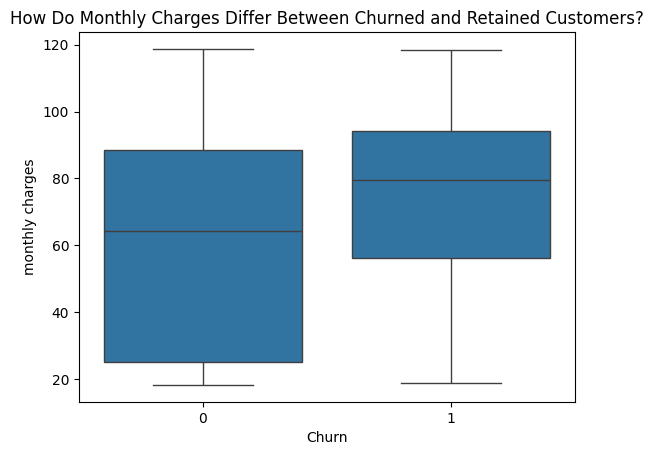

Churn percentage across monthly charge groups
Churn                       0          1
monthlyCharges_grp                      
low                 89.106628  10.893372
medium              76.057971  23.942029
high                62.178292  37.821708
very high           71.951220  28.048780


C:\Users\Admin\AppData\Local\Temp\ipykernel_20196\3605000048.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'monthlyCharges_grp'] = pd.cut(data['MonthlyCharges'],bins=bins,labels=label)


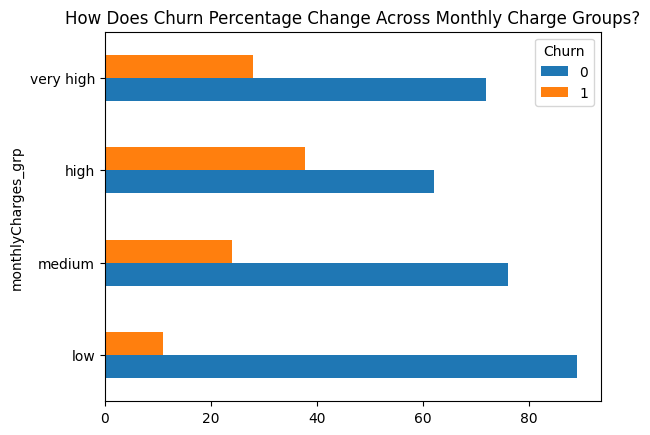

In [ ]:
#for monthly charges
print("Summary of Data")
print(data['MonthlyCharges'].describe())

print(f"\nAverage monthly charges of churned customers:{data.groupby("Churn")['MonthlyCharges'].mean()[1]:.2f}%")
print(f"Average monthly charges of retained customers:{data.groupby("Churn")['MonthlyCharges'].mean()[0]:.2f}%")
#distribution
sns.histplot(x='MonthlyCharges',bins=30,kde=True,data=data)
plt.title("What Is the Distribution of Monthly Charges?")
plt.xlabel("monthly charges")
plt.ylabel("frequency")
plt.show()

#summary using box plot
sns.boxplot(x="Churn",y="MonthlyCharges",data=data)
plt.title("How Do Monthly Charges Differ Between Churned and Retained Customers?")
plt.xlabel("Churn")
plt.ylabel("monthly charges")
plt.show()

#grouping
bins = [0,35,70,100,130]
label = ['low','medium','high','very high']
data.loc[:,'monthlyCharges_grp'] = pd.cut(data['MonthlyCharges'],bins=bins,labels=label)

monthly_chares_per = pd.crosstab(data['monthlyCharges_grp'],data['Churn'],normalize='index')*100
print("Churn percentage across monthly charge groups")
print(monthly_chares_per)
monthly_chares_per.plot(kind="barh")
plt.title("How Does Churn Percentage Change Across Monthly Charge Groups?")
plt.show()

<h4><b>INSIGHT:Customers With Higher Monthly Charges Tend to Churn More</b></h4>

Customers who churned had higher average monthly charges <b>₹74.44</b> compared to retained customers <b>₹61.27</b>. The churn rate increased as monthly charges increased, with high-charge customers showing the highest churn percentage. This indicates that higher monthly costs may contribute to customer churn.

<h4><b>Total Charges and Customer Churn Analysis</b></h4>

Summary of Data
count    7043.000000
mean     2281.916928
std      2265.270398
min        18.800000
25%       402.225000
50%      1397.475000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

Average total charges of churned customers:1531.80%
Average total charges of retained customers:2552.88%


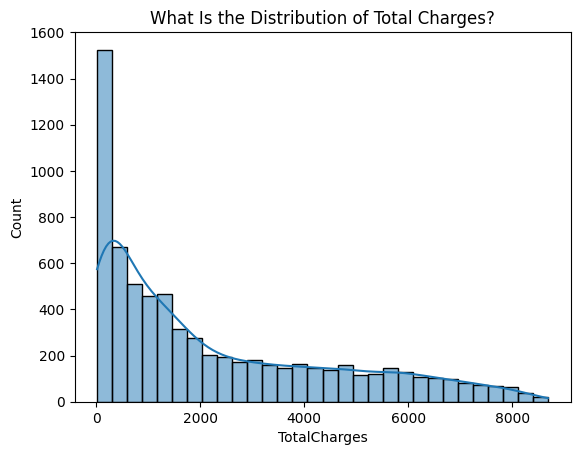

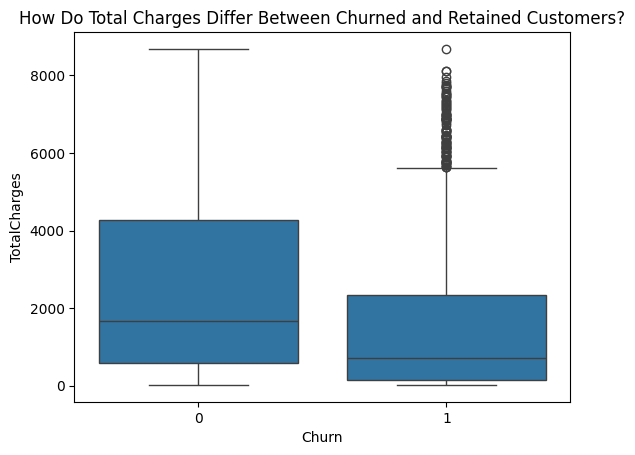

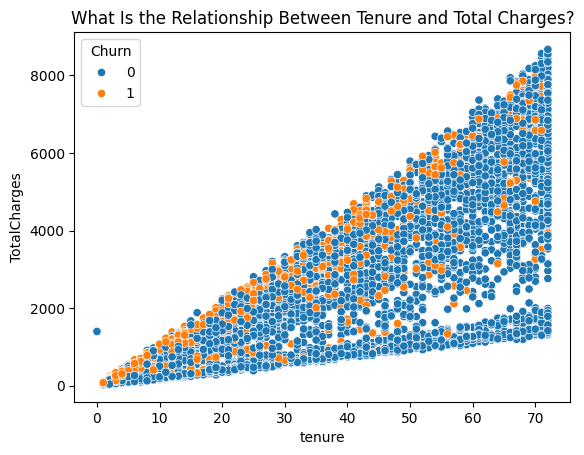

In [ ]:
#total charges
print("Summary of Data")
print(data['TotalCharges'].describe())

print(f"\nAverage total charges of churned customers:{data.groupby("Churn")['TotalCharges'].mean()[1]:.2f}%")
print(f"Average total charges of retained customers:{data.groupby("Churn")['TotalCharges'].mean()[0]:.2f}%")

sns.histplot(x='TotalCharges',bins=30,data=data,kde=True)
plt.title("What Is the Distribution of Total Charges?")
plt.show()

sns.boxplot(x='Churn',y='TotalCharges',data=data)
plt.title("How Do Total Charges Differ Between Churned and Retained Customers?")
plt.show()

sns.scatterplot(x='tenure',y='TotalCharges',data=data,hue="Churn")
plt.title("What Is the Relationship Between Tenure and Total Charges?")
plt.show()

<h4><b>INSIGHT:Retained Customers Have Higher Total Charges</b></h4>

Retained customers had much higher average total charges <b>₹2552.88</b> compared to churned customers <b>₹1531.80</b>. The scatter plot also shows that customers with longer tenure tend to accumulate higher total charges and are more likely to stay with the service. This indicates that long-term customers contribute more overall revenue.

<h4><b>Correlation Analysis of Tenure, Monthly Charges, and Total Charges</b></h4>

Correlation between tenure, monthly charges, and total charges
                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.247900      0.825464
MonthlyCharges  0.247900        1.000000      0.650864
TotalCharges    0.825464        0.650864      1.000000


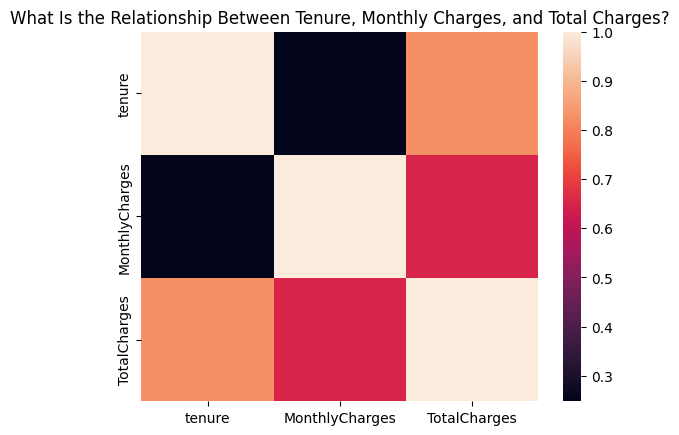

In [ ]:
#relationship between tenure,monthly and total charges
x = data[['tenure','MonthlyCharges','TotalCharges']].corr()
print("Correlation between tenure, monthly charges, and total charges")
print(x)

sns.heatmap(data=x)
plt.title("What Is the Relationship Between Tenure, Monthly Charges, and Total Charges?")
plt.show()

<h4><b>INSIGHT: Total Charges Strongly Depend on Tenure</b></h4>

The correlation analysis shows that Total Charges have a strong positive relationship with tenure, indicating that customers who stay longer generate higher overall revenue. Monthly Charges also contribute to Total Charges, but tenure has the strongest impact on accumulated customer spending.